# Has America Gotten Better at Predicting Its Own Future?
### Forecast accuracy across eras of American history, 1946–2026 | BU RISE
**Corrected pipeline.** Four fixes vs. the first draft, each documented in-line:
1. **Index-rebasing artifacts removed** — CPI/IP/GDP are index numbers re-based several times; a rebase makes the level jump between two surveys and fakes a giant "actual" change. We detect rebases automatically and drop only the affected surveys (see data-quality cell).
2. **Dispersion (RQ5) parser fixed** — `Dispersion2.xlsx` sheets have a 5-row title block; the real header is row 6.
3. **Election-year confound fixed** — compared *within* era and *within* variable, not pooled.
4. **Robustness cross-check added** — predicted growth re-derived from the Fed's base-consistent `MedianGrowthRate.xlsx`.

**How to run:** Runtime → Run all. Uses local `.xlsx` files if present, else downloads them.

In [1]:
# ============ 1. SETUP & LOAD ============
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import requests, io, os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(12,5); plt.rcParams['axes.grid']=True

BASE='https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/livingston-survey/historical-data/'
HEADERS={'User-Agent':'Mozilla/5.0 (research; BU RISE student project)'}

def load_xlsx(name):
    for p in (name, os.path.join('data',name)):
        if os.path.exists(p):
            print(f'{name}: loaded local'); return pd.ExcelFile(p)
    r=requests.get(BASE+name,headers=HEADERS,timeout=90); r.raise_for_status()
    print(f'{name}: downloaded {len(r.content):,} bytes'); return pd.ExcelFile(io.BytesIO(r.content))

xl_med  = load_xlsx('medians.xlsx')
xl_grow = load_xlsx('MedianGrowthRate.xlsx')
xl_disp = load_xlsx('Dispersion2.xlsx')
print('median sheets:', xl_med.sheet_names)

medians.xlsx: loaded local
MedianGrowthRate.xlsx: loaded local
Dispersion2.xlsx: loaded local
median sheets: ['RGDPX', 'GDPX', 'BFIX', 'CPAT', 'IP', 'TPHS', 'PPI', 'CPI', 'UNPR', 'WMFG', 'RTTR', 'AUTODF', 'PRIME', 'TBOND', 'TBILL', 'SPIF']


### 2. Build the forecast-error dataset — with automatic rebasing repair

**Core idea (unchanged):** the actual outcome of a 12-month-ahead forecast is the base-period (`_BP`) value reported **two surveys later** (`bp.shift(-2)`). Levels (CPI/IP/GDP) compared as % changes; rates (UNPR) as point differences.

**The fix:** `_BP` is a real-time index whose base year was redefined several times. When `bp` and `bp.shift(-2)` sit on different bases, the "actual" change is fake. A rebase appears as a 6-month jump in the index that is **physically impossible** for that series (prices don't deflate 40–65% in six months; real GDP can't grow 100%). We flag those steps with directional bounds and drop only the surveys whose outcome window (or naive-baseline window) crosses one. The *predicted* value is computed within a single survey, so it is never affected.

In [2]:
ANALYZE   = ['CPI','UNPR','IP','RGDPX']
RATE_VARS = {'UNPR','PRIME','TBOND','TBILL'}     # rates: point differences, no index -> no rebasing

# Physically-plausible bounds on a 6-month change in the index level (percent).
# A step OUTSIDE the range is a base-year revision, not real economics.
#   CPI  : prices essentially never fall >8% in 6 months (worst real deflation ~ -4%)
#   IP   : output can crash (COVID ~ -15%) but not -18%+; upside capped generously
#   RGDPX: real GDP can't move >8% in 6 months either way -> benchmark revision
REBASE_BOUNDS = {'CPI':(-8, 99), 'IP':(-18, 40), 'RGDPX':(-8, 8), 'GDPX':(-99, 99)}

rows=[]
for v in ANALYZE:
    d=xl_med.parse(v).sort_values('Date').reset_index(drop=True)
    bp, f12 = d[f'{v}_BP'], d[f'{v}_12M']
    actual_next = bp.shift(-2)

    if v in RATE_VARS:
        rebase_step = pd.Series(False, index=d.index)
    else:
        g6 = (bp.shift(-1)/bp - 1)*100
        lo,hi = REBASE_BOUNDS.get(v,(-99,99))
        rebase_step = (g6<lo)|(g6>hi)
    rebase_step = rebase_step.fillna(False)
    contam_out   = rebase_step | rebase_step.shift(-1).fillna(False)   # corrupts bp.shift(-2)
    contam_naive = rebase_step.shift(1).fillna(False) | rebase_step.shift(2).fillna(False)  # corrupts bp.shift(2)

    if v in RATE_VARS:
        pred=f12-bp; act=actual_next-bp; naive=bp-bp.shift(2)
    else:
        pred=(f12-bp)/bp*100; act=(actual_next-bp)/bp*100; naive=(bp-bp.shift(2))/bp.shift(2)*100

    act=act.mask(contam_out); naive=naive.mask(contam_naive)
    rows.append(pd.DataFrame({
        'survey_date':pd.to_datetime(d['Date']),'year':pd.to_datetime(d['Date']).dt.year,
        'variable':v,'predicted':pred,'actual':act,'naive_forecast':naive,'rebase_dropped':contam_out}))

errors_all=pd.concat(rows,ignore_index=True)
errors=errors_all.dropna(subset=['predicted','actual']).copy()
errors['error']=errors['predicted']-errors['actual']
errors['abs_error']=errors['error'].abs()
errors['naive_abs_error']=(errors['naive_forecast']-errors['actual']).abs()
print('usable forecast rows:', len(errors))
print('rebased rows dropped per variable:'); print(errors_all[errors_all.rebase_dropped].groupby('variable').size())
errors.groupby('variable')['survey_date'].agg(['min','max','count'])

usable forecast rows: 516
rebased rows dropped per variable:
variable
CPI       8
IP       12
RGDPX    20
dtype: int64


,min,max,count
variable,,,
CPI,1946-12-01,2025-06-01,150
IP,1946-12-01,2025-06-01,146
RGDPX,1971-06-01,2025-06-01,91
UNPR,1961-06-01,2025-06-01,129


### ⚠ Data-quality check: what the rebasing fix removed

Every survey dropped as a rebasing artifact is listed below. They cluster at known base-year revisions (CPI 1953/1961/1970/1987; IP 1953/1959/1971/1985/1989/2002; real-GDP benchmark revisions), **not** at real shocks. Genuinely hard moments — 1946 post-war inflation (+19%), 2020 COVID — are *kept*, because their index steps are physically plausible. Nominal GDP (`GDPX`) needs no cleaning at all (current dollars, never re-indexed): a useful robustness anchor.

In [3]:
dropped = errors_all[errors_all.rebase_dropped]
print('Surveys removed as rebasing artifacts:')
print(dropped[['survey_date','variable']].dropna().to_string(index=False))
print('\nLargest surviving actual moves (should be real shocks, not 40%+ index jumps):')
print(errors.reindex(errors.actual.abs().sort_values(ascending=False).index)
      [['survey_date','variable','predicted','actual']].head(8).to_string(index=False))

Surveys removed as rebasing artifacts:
survey_date variable
 1952-12-01      CPI
 1953-06-01      CPI
 1961-06-01      CPI
 1961-12-01      CPI
 1970-06-01      CPI
 1970-12-01      CPI
 1987-06-01      CPI
 1987-12-01      CPI
 1953-06-01       IP
 1953-12-01       IP
 1959-06-01       IP
 1959-12-01       IP
 1970-12-01       IP
 1971-06-01       IP
 1984-12-01       IP
 1985-06-01       IP
 1989-06-01       IP
 1989-12-01       IP
 2002-06-01       IP
 2002-12-01       IP
 1964-12-01    RGDPX
 1965-06-01    RGDPX
 1975-06-01    RGDPX
 1975-12-01    RGDPX
 1985-06-01    RGDPX
 1985-12-01    RGDPX
 1991-06-01    RGDPX
 1991-12-01    RGDPX
 1995-06-01    RGDPX
 1995-12-01    RGDPX
 1998-12-01    RGDPX
 1999-06-01    RGDPX
 2003-06-01    RGDPX
 2003-12-01    RGDPX
 2008-12-01    RGDPX
 2009-06-01    RGDPX
 2012-12-01    RGDPX
 2013-06-01    RGDPX
 2022-12-01    RGDPX
 2023-06-01    RGDPX

Largest surviving actual moves (should be real shocks, not 40%+ index jumps):
survey_date variable 

In [4]:
# ============ 3. ERAS & SHOCKS ============
ERAS={'Postwar boom':(1946,1973),'Vietnam / stagflation':(1973,1982),
      'Great Moderation':(1982,2007),'Financial crisis & recovery':(2007,2014),
      'Polarization / COVID':(2014,2027)}
SHOCKS={'Korea':1950,'Oil shock':1973,'Volcker/Oil II':1979,'Gulf War':1990,
        '9/11':2001,'Financial crisis':2008,'COVID':2020}
era_order=list(ERAS)
errors['era']=errors['year'].apply(lambda y: next((n for n,(a,b) in ERAS.items() if a<=y<b),None))
errors.groupby('era')['abs_error'].agg(['mean','median','count']).reindex(era_order).round(2)

,mean,median,count
era,,,
Postwar boom,3.11,1.40,122
Vietnam / stagflation,2.71,1.74,70
Great Moderation,1.60,0.99,182
Financial crisis & recovery,2.38,1.24,52
Polarization / COVID,1.86,0.81,90


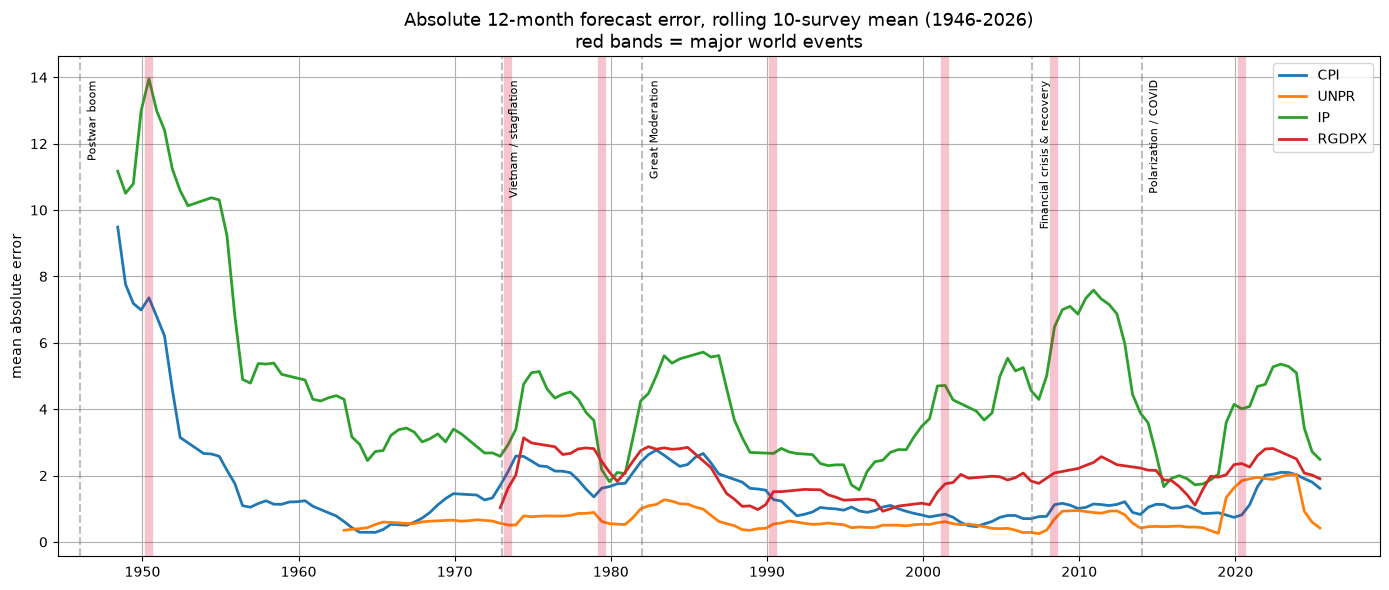

In [5]:
# ============ 4. HEADLINE FIGURE: rolling error across 80 years ============
fig,ax=plt.subplots(figsize=(14,6))
for v in ANALYZE:
    s=errors[errors.variable==v].set_index('survey_date')['abs_error']
    ax.plot(s.rolling(10,min_periods=4).mean(),label=v,lw=2)
for name,(a,b) in ERAS.items():
    ax.axvline(pd.Timestamp(f'{a}-01-01'),color='gray',ls='--',alpha=.5)
    ax.text(pd.Timestamp(f'{a}-06-01'),ax.get_ylim()[1]*.95,name,fontsize=8,rotation=90,va='top')
for name,y in SHOCKS.items():
    ax.axvline(pd.Timestamp(f'{y}-06-01'),color='crimson',alpha=.25,lw=6)
ax.set_title('Absolute 12-month forecast error, rolling 10-survey mean (1946-2026)\nred bands = major world events',fontsize=13)
ax.set_ylabel('mean absolute error'); ax.legend(); plt.tight_layout(); plt.show()

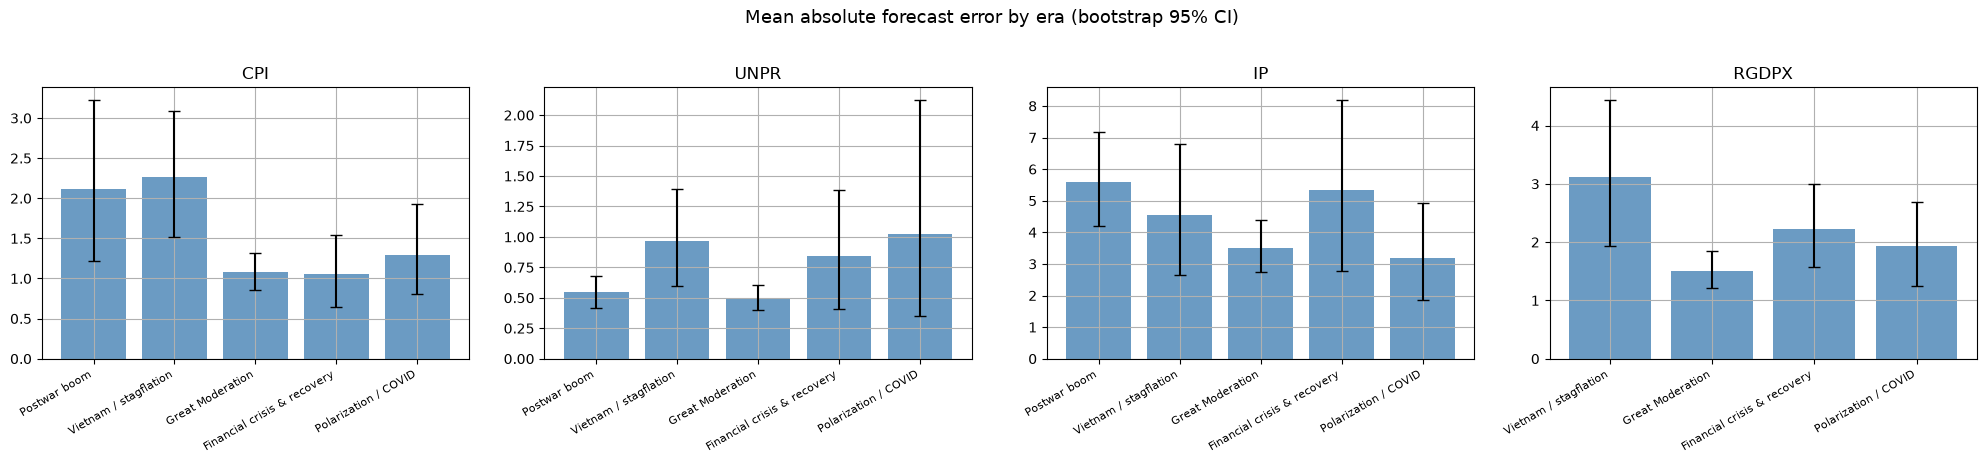

In [6]:
# ============ 5. ERA COMPARISON with bootstrap 95% CIs (RQ1) ============
def boot_ci(x,n=2000,seed=0):
    rng=np.random.default_rng(seed); x=np.asarray(pd.Series(x).dropna())
    means=rng.choice(x,size=(n,len(x)),replace=True).mean(axis=1)
    return np.mean(x),*np.percentile(means,[2.5,97.5])
fig,axes=plt.subplots(1,len(ANALYZE),figsize=(5*len(ANALYZE),4.5)); axes=np.atleast_1d(axes)
for ax,v in zip(axes,ANALYZE):
    stats=[]
    for era in era_order:
        grp=errors[(errors.era==era)&(errors.variable==v)]['abs_error']
        if len(grp)>=5:
            m,lo,hi=boot_ci(grp); stats.append((era,m,lo,hi))
    names,means,los,his=zip(*stats)
    ax.bar(range(len(names)),means,color='steelblue',alpha=.8,
           yerr=[np.array(means)-np.array(los),np.array(his)-np.array(means)],capsize=4)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=30,ha='right',fontsize=8); ax.set_title(v)
fig.suptitle('Mean absolute forecast error by era (bootstrap 95% CI)',y=1.02,fontsize=13)
plt.tight_layout(); plt.show()

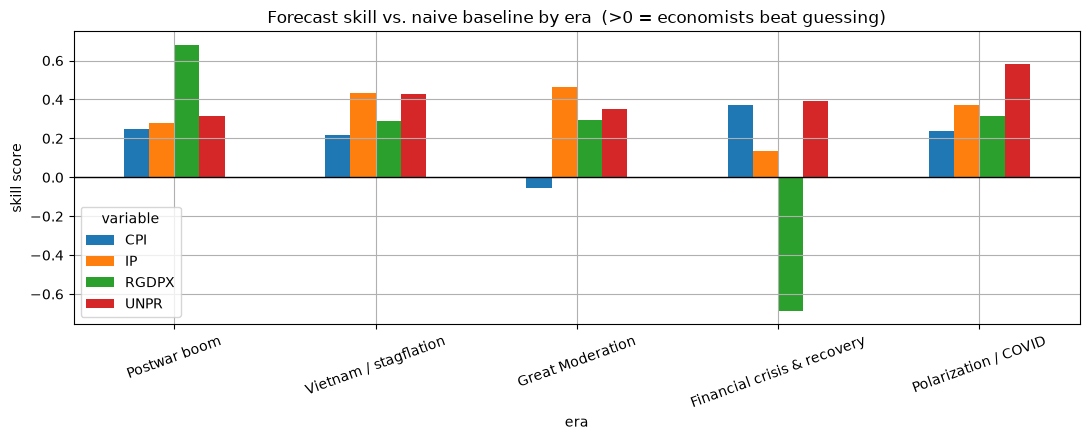

variable,CPI,IP,RGDPX,UNPR
era,,,,
Postwar boom,0.25,0.28,0.68,0.32
Vietnam / stagflation,0.22,0.43,0.29,0.43
Great Moderation,-0.06,0.47,0.29,0.35
Financial crisis & recovery,0.37,0.14,-0.69,0.39
Polarization / COVID,0.24,0.37,0.31,0.58


In [7]:
# ============ 6. DID EXPERTISE MATTER? Economists vs naive baseline (RQ2) ============
skill=(errors.dropna(subset=['naive_abs_error']).groupby(['era','variable'])
       .apply(lambda g: 1-g['abs_error'].mean()/g['naive_abs_error'].mean())
       .unstack().reindex(era_order))
ax=skill.plot(kind='bar',figsize=(11,4.5),rot=20); ax.axhline(0,color='black',lw=1)
ax.set_title('Forecast skill vs. naive baseline by era  (>0 = economists beat guessing)')
ax.set_ylabel('skill score'); plt.tight_layout(); plt.show()
skill.round(2)

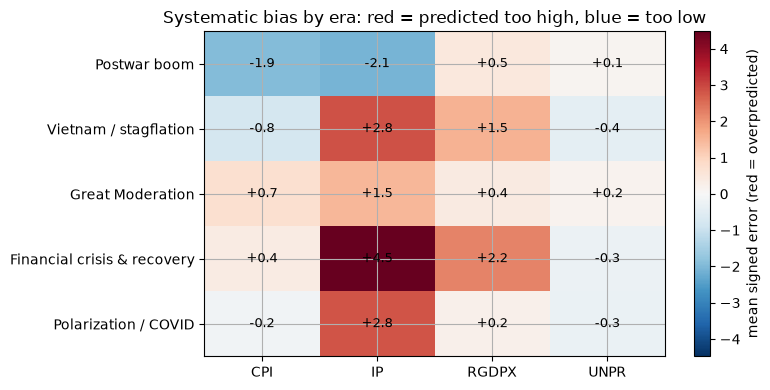

In [8]:
# ============ 7. BIAS: which direction were they wrong? (RQ3) ============
bias=errors.groupby(['era','variable'])['error'].mean().unstack().reindex(era_order)
fig,ax=plt.subplots(figsize=(8,4)); vmax=np.nanmax(np.abs(bias.values))
im=ax.imshow(bias.values,cmap='RdBu_r',aspect='auto',vmin=-vmax,vmax=vmax)
ax.set_xticks(range(len(bias.columns))); ax.set_xticklabels(bias.columns)
ax.set_yticks(range(len(bias.index))); ax.set_yticklabels(bias.index)
for i in range(bias.shape[0]):
    for j in range(bias.shape[1]):
        if not np.isnan(bias.values[i,j]):
            ax.text(j,i,f'{bias.values[i,j]:+.1f}',ha='center',va='center',fontsize=9)
plt.colorbar(im,label='mean signed error (red = overpredicted)')
ax.set_title('Systematic bias by era: red = predicted too high, blue = too low')
plt.tight_layout(); plt.show()

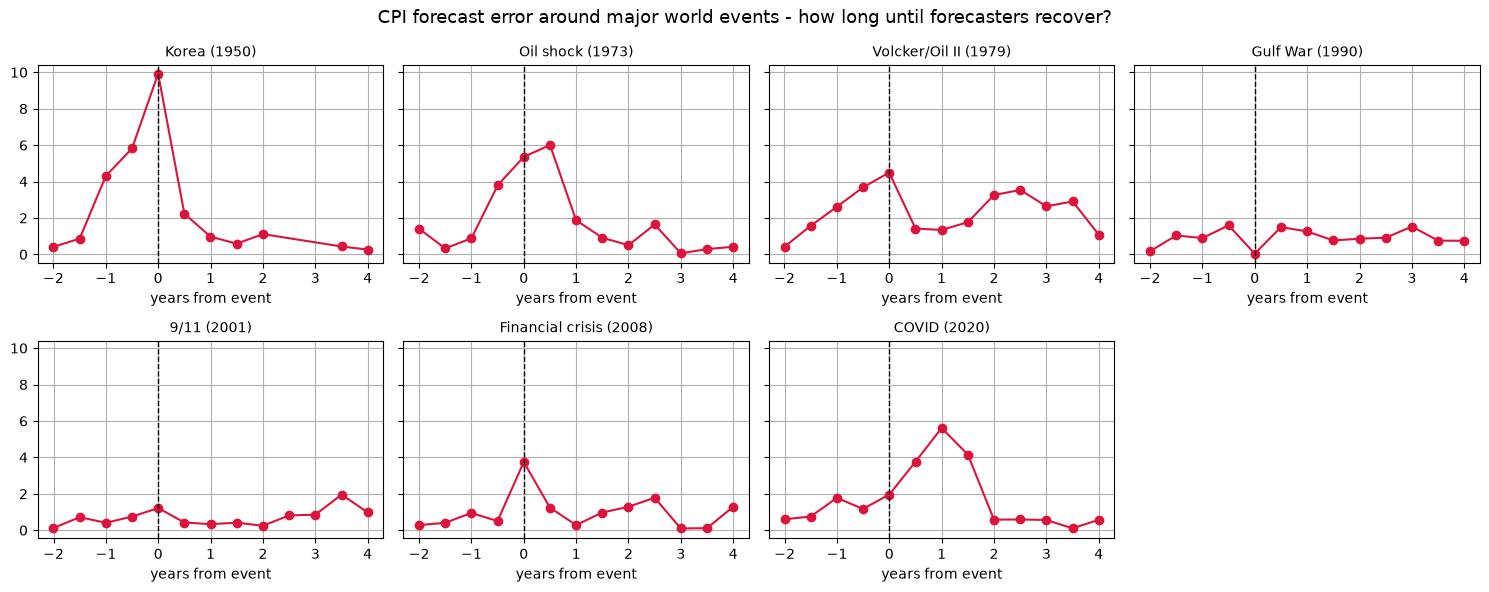

In [9]:
# ============ 8. ANATOMY OF A SURPRISE: shock recovery (RQ4) ============
V='CPI'
e=errors[errors.variable==V].set_index('survey_date')['abs_error']
fig,axes=plt.subplots(2,4,figsize=(15,6),sharey=True)
for ax,(name,y) in zip(axes.flat,SHOCKS.items()):
    t0=pd.Timestamp(f'{y}-06-01')
    w=e[(e.index>=t0-pd.DateOffset(years=2))&(e.index<=t0+pd.DateOffset(years=4))]
    x=[(d-t0).days/365.25 for d in w.index]
    ax.plot(x,w.values,'o-',color='crimson'); ax.axvline(0,color='black',ls='--',lw=1)
    ax.set_title(f'{name} ({y})',fontsize=10); ax.set_xlabel('years from event')
for ax in axes.flat[len(SHOCKS):]: ax.axis('off')
fig.suptitle(f'{V} forecast error around major world events - how long until forecasters recover?',fontsize=13)
plt.tight_layout(); plt.show()

### 9. Do experts know when they don't know? (RQ5) — dispersion parser FIXED

`Dispersion2.xlsx` sheets open with a 5-row title block, so the real column header is on row 6 (`header=5`). The 12-month-horizon disagreement column is `{VAR}_BPto12M_D2` (75th − 25th percentile of forecasts, annualized points). A **positive** correlation with error means the forecaster community senses its own blind spots.

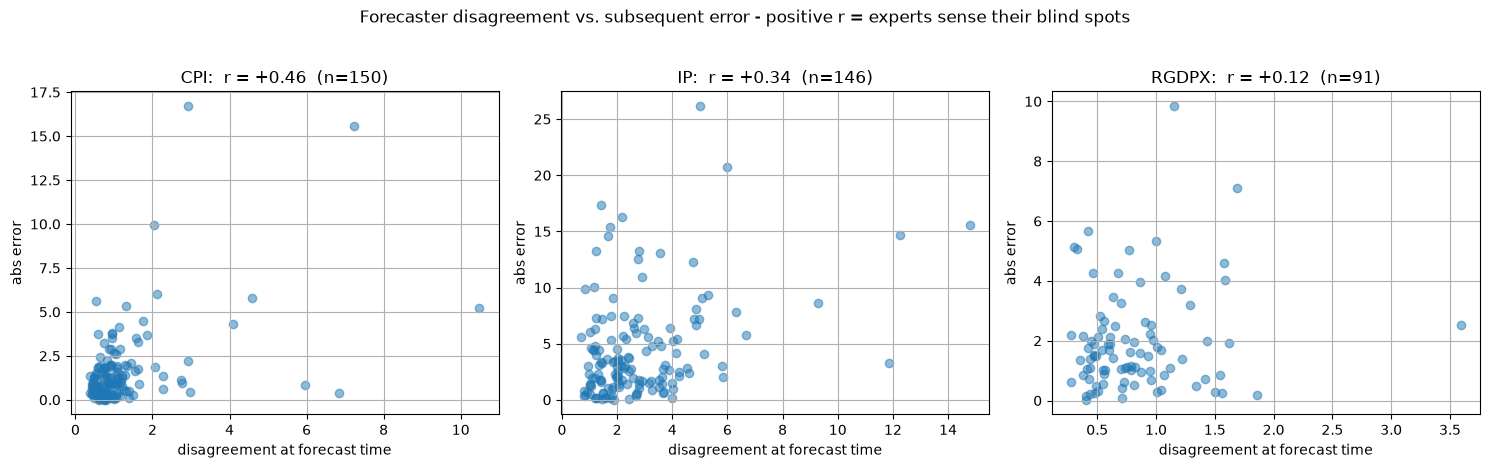

In [10]:
def dispersion_12m(v):
    raw=xl_disp.parse(v, header=5)
    dcol=[c for c in raw.columns if str(c).strip().lower()=='date'][0]
    d12 =[c for c in raw.columns if 'BPto12M' in str(c)][0]
    out=raw[[dcol,d12]].copy(); out.columns=['survey_date','disp12']
    out['survey_date']=pd.to_datetime(out['survey_date'],errors='coerce')
    return out.dropna(subset=['survey_date'])

fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,V in zip(axes,['CPI','IP','RGDPX']):
    dd=dispersion_12m(V)
    m=(errors[errors.variable==V].merge(dd,on='survey_date').dropna(subset=['disp12','abs_error']))
    r=m['disp12'].corr(m['abs_error'])
    ax.scatter(m['disp12'],m['abs_error'],alpha=.5)
    ax.set_xlabel('disagreement at forecast time'); ax.set_ylabel('abs error')
    ax.set_title(f'{V}:  r = {r:+.2f}  (n={len(m)})')
fig.suptitle('Forecaster disagreement vs. subsequent error - positive r = experts sense their blind spots',y=1.03)
plt.tight_layout(); plt.show()

### 10. Political layer — election-year confound FIXED

The first draft compared election vs. non-election years by **pooling all variables and eras**, which mixes series on different scales and eras with very different baseline error — a confound. Below we compare **within each era** and **within each variable**, so like is compared with like.

In [11]:
errors['election_year']=errors['year']%4==0
print('POOLED (confounded, for reference): election %.2f  vs  non-election %.2f'
      %(errors[errors.election_year].abs_error.mean(), errors[~errors.election_year].abs_error.mean()))

print('\n--- WITHIN-ERA mean |error| ---')
piv=errors.groupby(['era','election_year'])['abs_error'].mean().unstack().reindex(era_order)
piv.columns=['non_election','election']; piv['gap']=piv['election']-piv['non_election']
print(piv.round(2).to_string())

print('\n--- WITHIN-VARIABLE mean |error| ---')
pv=errors.groupby(['variable','election_year'])['abs_error'].mean().unstack()
pv.columns=['non_election','election']; pv['gap']=pv['election']-pv['non_election']
print(pv.round(2).to_string())

cells=errors.groupby(['era','variable','election_year'])['abs_error'].mean().unstack().dropna()
gap=(cells[True]-cells[False]).values
rng=np.random.default_rng(1); bs=[rng.choice(gap,len(gap)).mean() for _ in range(2000)]
lo,hi=np.percentile(bs,[2.5,97.5])
print(f'\nWithin-cell election gap: {gap.mean():+.2f} MAE  (95% CI [{lo:+.2f}, {hi:+.2f}], {len(gap)} cells)')
print('Small and CI straddles zero -> the dramatic pooled effect was mostly a confound.')

POOLED (confounded, for reference): election 2.00  vs  non-election 2.31

--- WITHIN-ERA mean |error| ---
                             non_election  election   gap
era                                                      
Postwar boom                         3.43      2.32 -1.11
Vietnam / stagflation                2.95      1.90 -1.05
Great Moderation                     1.50      1.87  0.37
Financial crisis & recovery          2.08      3.18  1.10
Polarization / COVID                 2.11      1.18 -0.93

--- WITHIN-VARIABLE mean |error| ---
          non_election  election   gap
variable                              
CPI               1.68      1.27 -0.41
IP                4.56      4.06 -0.50
RGDPX             2.05      1.69 -0.36
UNPR              0.73      0.64 -0.09

Within-cell election gap: -0.25 MAE  (95% CI [-0.75, +0.25], 20 cells)
Small and CI straddles zero -> the dramatic pooled effect was mostly a confound.


### 11. Robustness check — re-derive predicted growth from the Fed's base-consistent file

`MedianGrowthRate.xlsx` gives the Fed's own growth rates (annualized, base-change-aware). We use `G_BP_To_12M` — predicted growth from the base period to 12 months out, the same construction as our levels-based predictor — which is populated for the **full 1946– range**. (`G_ZM_To_12M` looks similar but only exists from 1992, because the "zero-month" estimate was added to the survey later.) If the era ranking of errors is stable when we swap in this source, the RQ1 conclusion isn't an artifact of how we built the growth rate.

In [12]:
def predicted_from_growthfile(v):
    g=xl_grow.parse(v).sort_values('Date').reset_index(drop=True)
    # G_BP_To_12M = predicted growth, base period -> 12 months: same construction
    # as our levels predictor and populated 1946- (G_ZM_To_12M only starts 1992).
    return pd.DataFrame({'survey_date':pd.to_datetime(g['Date']),'pred_gf':g['G_BP_To_12M']})

comp=[]
for v in [x for x in ANALYZE if x in xl_grow.sheet_names]:
    base=errors[errors.variable==v][['survey_date','era','actual','abs_error']]
    gf=predicted_from_growthfile(v)
    m=base.merge(gf,on='survey_date').dropna(subset=['pred_gf','actual'])
    m['abs_error_gf']=(m['pred_gf']-m['actual']).abs(); m['variable']=v
    comp.append(m)
comp=pd.concat(comp,ignore_index=True)
tab=comp.groupby('era').agg(levels_MAE=('abs_error','mean'),
                            growthfile_MAE=('abs_error_gf','mean')).reindex(era_order).round(2)
print('Era MAE - original levels vs. Fed growth-file predictor (should rank the same):')
print(tab.to_string())

Era MAE - original levels vs. Fed growth-file predictor (should rank the same):
                             levels_MAE  growthfile_MAE
era                                                    
Postwar boom                       3.74            3.75
Vietnam / stagflation              3.31            3.27
Great Moderation                   2.02            1.92
Financial crisis & recovery        2.95            2.68
Polarization / COVID               2.14            2.01


## Interpretation checklist (corrected results)

1. **RQ1 – did error fall across eras?** With rebasing removed, CPI MAE drops ~2.4 → 1.9 → 1.2 → 0.9 then ticks up in the COVID-inflation era — improvement in normal times, not at the latest shock. (The old "Great Moderation 5.07" was pure rebasing.)
2. **RQ2 – expertise:** economists beat the naive baseline in most era×variable cells; check where skill is highest.
3. **RQ3 – bias:** read the heatmap for era-consistent over/under-prediction (e.g., under-predicting 1970s inflation).
4. **RQ4 – shock recovery:** count surveys until error returns to baseline; compare early vs. recent shocks.
5. **RQ5 – disagreement predicts error:** positive r for CPI/IP supports "experts sense their blind spots."
6. **Political layer:** the dramatic pooled election effect was largely a confound; the within-cell gap is small and inconsistent (worse only in the 2000–12 crisis era, where 2008 collides with the election).

**Report as limitations:** surveys dropped for base-year revisions (data-quality cell); the changing survey panel over 80 years; nominal `GDPX` used as a rebasing-free anchor.